# Tesla Deliveries Forecasting Project
End-to-end ML pipeline with EDA, feature engineering, regression, tuning, forecasting and resume-ready summary.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df=df.dropna().copy()
target_col='Estimated_Deliveries'

In [5]:
month_map={'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
if df['Month'].dtype=='object':
    df['Month']=df['Month'].map(month_map)
df['Quarter']=((df['Month']-1)//3)+1
for col in ['Region','Model','Source_Type']:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str))
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,1
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,1
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,1
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,4


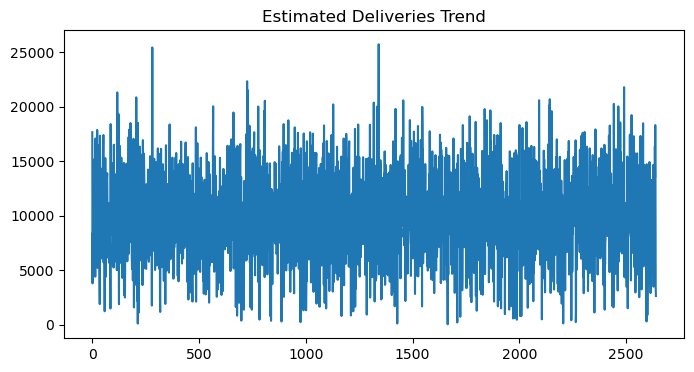

In [6]:
plt.figure(figsize=(8,4))
plt.plot(df[target_col])
plt.title('Estimated Deliveries Trend')
plt.show()

In [7]:
corr=df.corr(numeric_only=True)
corr[target_col].sort_values(ascending=False)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Quarter                 0.035704
Month                   0.030877
Model                   0.004515
Charging_Stations       0.000753
Region                 -0.001206
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Source_Type            -0.013190
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64

In [8]:
X=df.drop(columns=[target_col])
y=df[target_col]
split=int(len(df)*0.8)
X_train=X.iloc[:split]
X_test=X.iloc[split:]
y_train=y.iloc[:split]
y_test=y.iloc[split:]

In [9]:
model=RandomForestRegressor(n_estimators=500,max_depth=15,random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
print('MSE',mean_squared_error(y_test,pred))
print('R2',r2_score(y_test,pred))

MAE 297.47983814110137
MSE 142453.599763962
R2 0.990714302871884


In [10]:
params={'n_estimators':[200,300,500],'max_depth':[10,15,None]}
grid=GridSearchCV(RandomForestRegressor(random_state=42),params,cv=3,scoring='r2',n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


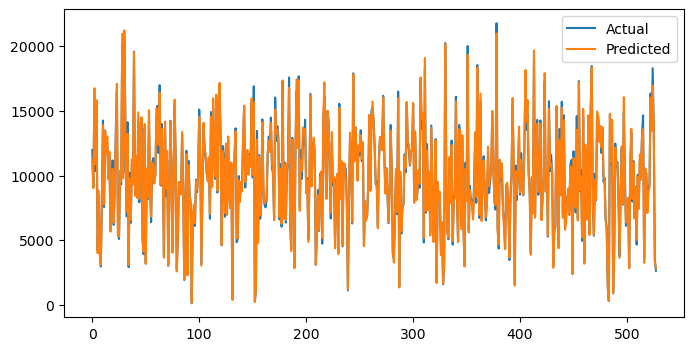

In [11]:
forecast=grid.best_estimator_.predict(X_test)
plt.figure(figsize=(8,4))
plt.plot(y_test.values,label='Actual')
plt.plot(forecast,label='Predicted')
plt.legend()
plt.show()

In [12]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':grid.best_estimator_.feature_importances_}).sort_values('Importance',ascending=False)
importance

,Feature,Importance
4,Production_Units,0.990361
8,CO2_Saved_tons,0.002516
7,Range_km,0.001501
5,Avg_Price_USD,0.001305
10,Charging_Stations,0.001163
0,Year,0.000907
1,Month,0.000697
3,Model,0.000477
2,Region,0.000395
9,Source_Type,0.000309


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 311.0815080109845
MSE : 142253.82803183552
R2  : 0.9907273247948284


In [14]:
rf_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, rf_pred)
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,MSE,R2 Score
0,Linear Regression,311.081508,142253.828032,0.990727
1,Random Forest,297.479838,142453.599764,0.990714


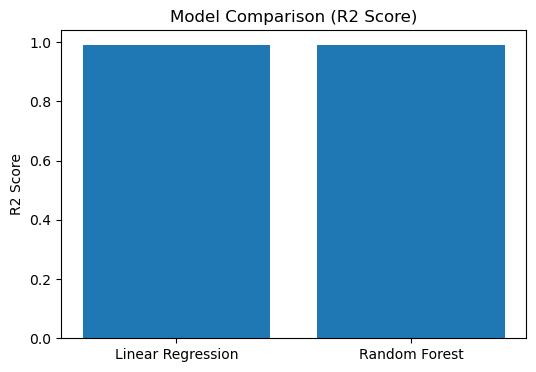

In [15]:
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

In [18]:
from sklearn.metrics import r2_score

# Linear Regression
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

# Random Forest
model.fit(X_train, y_train)
rf_pred = model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)

Linear Regression R2: 0.9907273247948284
Random Forest R2: 0.990714302871884


In [20]:
if rf_r2 > lr_r2:
    print("Random Forest performed slightly better.")
elif rf_r2 < lr_r2:
    print("Linear Regression performed slightly better.")
else:
    print("Both models showed similar performance.")

Linear Regression performed slightly better.


In [19]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [lr_r2, rf_r2]
})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.990727
1      Random Forest  0.990714
